In [319]:
import pandas as pd
import numpy as np
import ydata_profiling
from ydata_profiling import ProfileReport
import os
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [320]:
pd.options.display.float_format = '{:.2f}'.format
pd.options.display.max_rows = 100
pd.options.display.max_columns = 25



In [321]:
data = pd.read_csv(r"C:\Users\ACER\OneDrive\Desktop\ML Notes and colab Notebooks\Data Science Projects\Cryptoprice-prediction\notebook\data\Crypto_dataset.csv")

In [322]:
data["Unnamed: 0"]

0            0
1            1
2            2
3            3
4            4
         ...  
72941    72941
72942    72942
72943    72943
72944    72944
72945    72945
Name: Unnamed: 0, Length: 72946, dtype: int64

## check feature -  Unnamed: 0 found it is indexing feature hence remnoving from dataframe
## Check feature - data and timestamp found they are having same data hence removing timestamp feature from dataframe


In [323]:
df = data.drop(columns= ["Unnamed: 0",'timestamp'])

In [324]:
df.sample(3)

,open,high,low,close,volume,marketCap,crypto_name,date
29035,301.31,309.79,300.31,307.01,1362441598.18,5523893244.04,Bitcoin Cash,2019-09-08
16337,0.15,0.15,0.14,0.15,10195300.00,94611506.01,Theta Network,2018-06-20
19518,0.05,0.05,0.05,0.05,32365800.00,105423894.34,Ravencoin,2018-10-28


In [325]:
df.date = pd.to_datetime(df.date)
numeric_features = [i for i in df.columns if df[i].dtype !='O'] 
df['variation'] = ((df['high'] - df['low'])/df['low'])*100


In [326]:
df.date

0       2013-05-05
1       2013-05-05
2       2013-05-06
3       2013-05-06
4       2013-05-07
           ...    
72941   2022-10-23
72942   2022-10-23
72943   2022-10-23
72944   2022-10-23
72945   2022-10-23
Name: date, Length: 72946, dtype: datetime64[ns]

In [327]:
numeric_features

['open', 'high', 'low', 'close', 'volume', 'marketCap', 'date']

In [328]:
numeric_df = df[numeric_features]
numeric_df = numeric_df.drop(columns= ['date'])

In [329]:
report = ProfileReport(df)

In [330]:
report

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:00<00:00, 22.12it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [331]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72946 entries, 0 to 72945
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   open         72946 non-null  float64       
 1   high         72946 non-null  float64       
 2   low          72946 non-null  float64       
 3   close        72946 non-null  float64       
 4   volume       72946 non-null  float64       
 5   marketCap    72946 non-null  float64       
 6   crypto_name  72946 non-null  object        
 7   date         72946 non-null  datetime64[ns]
 8   variation    72946 non-null  float64       
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 5.0+ MB


In [332]:
df.isnull().sum()

open           0
high           0
low            0
close          0
volume         0
marketCap      0
crypto_name    0
date           0
variation      0
dtype: int64

In [333]:
categorical_features = [i for i in df.columns if df[i].dtype =='O']


In [334]:
for i in numeric_features:
    print(f'Max of feature {i} is = {df[i].max()},min of feature {i} is = {df[i].min()}')

Max of feature open is = 67549.7355807849,min of feature open is = 0.0
Max of feature high is = 162188.2554365376,min of feature high is = 1.0221e-10
Max of feature low is = 66458.7237330132,min of feature low is = 0.0
Max of feature close is = 67566.8300878775,min of feature close is = 8.292e-11
Max of feature volume is = 350967941479.06,min of feature volume is = 0.0
Max of feature marketCap is = 1274831490851.01,min of feature marketCap is = 0.0
Max of feature date is = 2022-10-23 00:00:00,min of feature date is = 2013-05-05 00:00:00


## Univariate Analysis

In [335]:
uni_df = df.groupby('crypto_name').mean().sort_values(by='marketCap', ascending=False).reset_index()
uni_df

,crypto_name,open,high,low,close,volume,marketCap,date,variation
0,Bitcoin,9682.45,9937.63,9403.19,9694.59,12434835924.94,177792088837.04,2017-10-21 04:48:10.640393984,5.18
1,Ethereum,681.08,704.34,655.43,682.36,8157792631.51,77636561095.63,2018-12-09 11:27:55.247524608,8.08
2,Polkadot,20.63,21.63,19.54,20.68,1691898619.18,19718622946.72,2021-07-10 18:39:43.701188352,10.80
3,BNB,110.80,114.87,106.46,111.08,828182328.11,17744166293.76,2019-12-07 06:08:51.770222592,9.06
4,Solana,50.51,53.04,48.03,50.64,1017567195.56,15215590401.96,2021-05-01 11:57:59.665738240,13.22
5,Cardano,0.45,0.47,0.43,0.45,1107880904.39,14077252970.14,2020-01-10 18:51:25.714285824,9.56
6,Tether,1.00,1.01,1.00,1.00,23906983721.14,13189526187.67,2018-09-20 22:09:00.975987712,1.02
7,XRP,0.28,0.30,0.27,0.28,1369412516.76,12141543656.74,2017-12-05 21:26:17.066835456,7.72
8,USD Coin,1.00,1.01,1.00,1.00,1385022142.70,11468438200.77,2020-07-18 16:32:59.146919424,1.09
9,Bitcoin Cash,518.15,544.44,491.04,518.06,2132186102.40,9151861927.89,2019-12-06 05:47:21.217798400,9.24


In [336]:
crypto_names = list(df.crypto_name.unique())
crypto_names


['Bitcoin',
 'Litecoin',
 'XRP',
 'Dogecoin',
 'Monero',
 'Stellar',
 'Tether',
 'Ethereum',
 'Ethereum Classic',
 'Maker',
 'Basic Attention Token',
 'EOS',
 'Bitcoin Cash',
 'BNB',
 'TRON',
 'Decentraland',
 'Chainlink',
 'Cardano',
 'Filecoin',
 'Theta Network',
 'Huobi Token',
 'Ravencoin',
 'Tezos',
 'VeChain',
 'Quant',
 'USD Coin',
 'Cronos',
 'Wrapped Bitcoin',
 'Cosmos',
 'Polygon',
 'OKB',
 'UNUS SED LEO',
 'Algorand',
 'Chiliz',
 'THORChain',
 'Terra Classic',
 'FTX Token',
 'Hedera',
 'Binance USD',
 'Dai',
 'Solana',
 'Avalanche',
 'Shiba Inu',
 'The Sandbox',
 'Polkadot',
 'Elrond',
 'Uniswap',
 'Aave',
 'NEAR Protocol',
 'Flow',
 'Internet Computer',
 'Casper',
 'Toncoin',
 'Chain',
 'ApeCoin',
 'Aptos']

In [337]:
names = ["Bitcoin", "Ethereum", "XRP", "Polkadot", "BNB", "Solana", "Cardano", "Tether"]
top_crypto = list([df[df.crypto_name == name] for name in names])


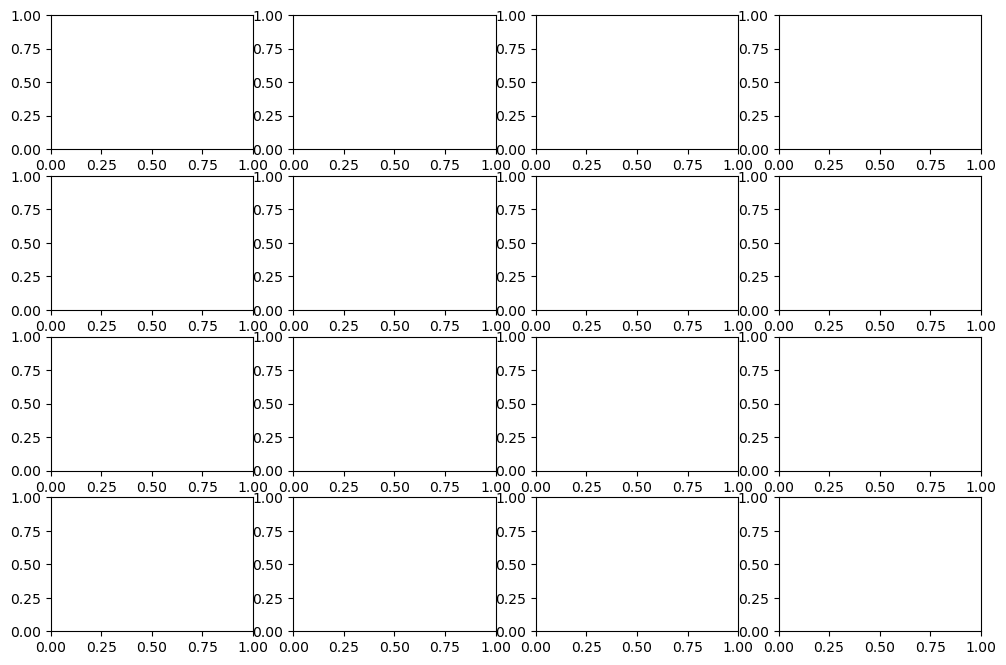

In [338]:

# Activates the 4th cell in a 4x4 grid
plt.figure(figsize = [12,8])
for i in range(1,17):
    plt.subplot(4, 4, i)
plt.show()


In [339]:
df[df['crypto_name'] == "BNB"].max()

open                        676.32
high                        690.93
low                         634.55
close                       675.68
volume              17982945189.09
marketCap          109140493552.58
crypto_name                    BNB
date           2022-10-23 00:00:00
variation                   157.20
dtype: object

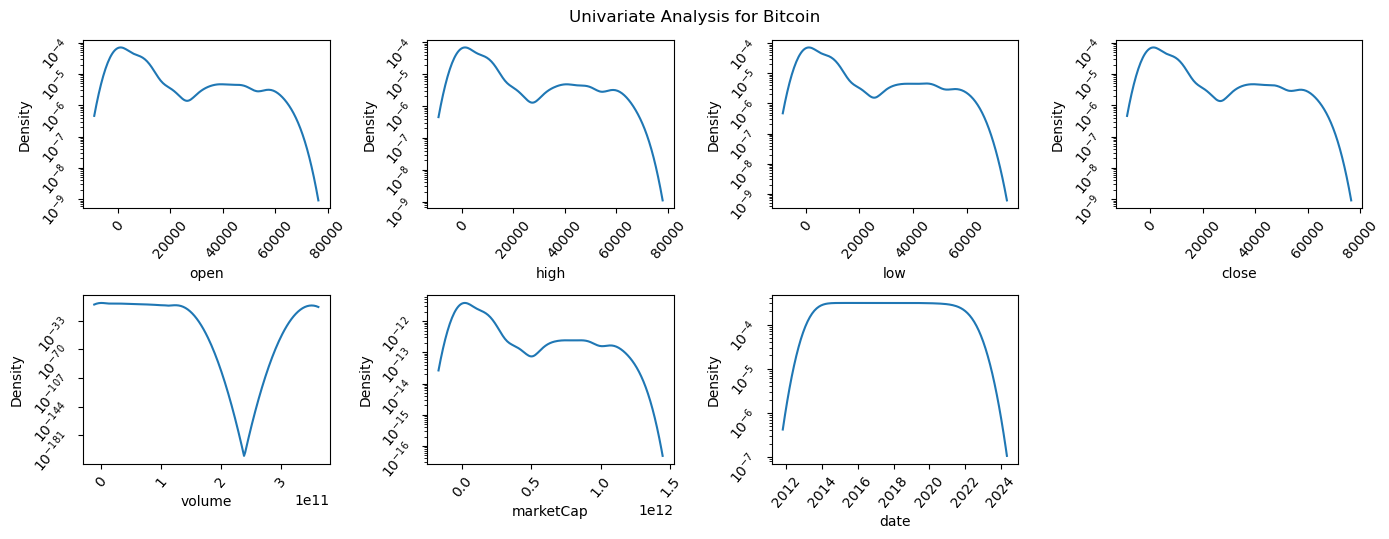

In [340]:
bitcoin_df = df[df['crypto_name'] == 'Bitcoin']

plt.figure(figsize=[14, 10])
plt.suptitle('Univariate Analysis for Bitcoin')

for i, feature in enumerate(numeric_features):
    plt.subplot(4, 4, i + 1)
    sns.kdeplot(data=bitcoin_df, x=feature)
    plt.xticks(rotation=50, fontsize=10, color='black')
    plt.yticks(rotation=50, fontsize=10, color='black')
    plt.yscale('log')
    plt.xlabel(feature)

plt.tight_layout()
plt.show()

**Bitcoin**
- **open, high, low, close** — picks are appeared  near $0–5,000, a smaller one around $30,000–40,000, and another around $55,000–65,000. This confirms Bitcoin spent extended periods at multiple distinct price levels (different market cycles), not just one dominant low band with a long thin tail. The log-scale makes each cycle visible instead of hiding the smaller ones under the main peak.
- **marketCap** — same three-bump structure as the price columns, as expected since marketCap tracks price directly.
- **date** — same flat-topped plateau as before, now just rendered on a log y-axis (which doesn't change its shape much since it was already fairly flat).

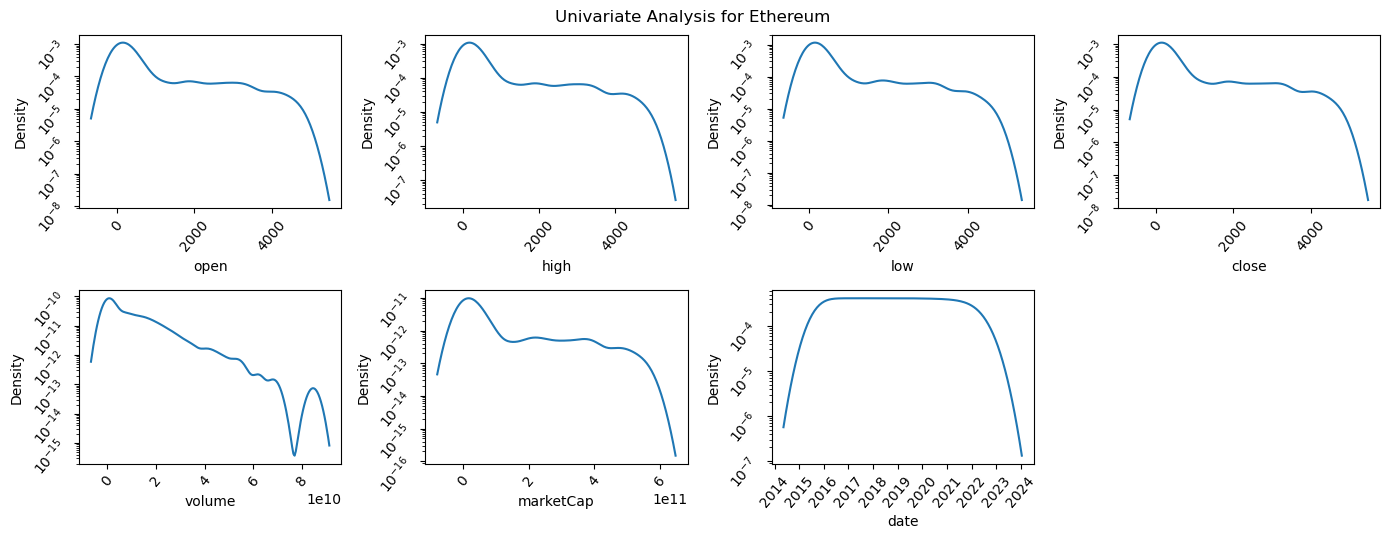

In [342]:
eth_df = df[df['crypto_name'] == 'Ethereum']

plt.figure(figsize=[14, 10])
plt.suptitle('Univariate Analysis for Ethereum ')

for i, feature in enumerate(numeric_features):
    plt.subplot(4, 4, i + 1)
    sns.kdeplot(data=eth_df, x=feature)
    plt.xticks(rotation=50, fontsize=10, color='black')
    plt.yticks(rotation=50, fontsize=10, color='black')
    plt.yscale('log')
    plt.xlabel(feature)

plt.tight_layout()
plt.show()

**Ethereum**
- **open, high, low, close**: These are also very similar to each other. The distributions are strongly right-skewed: most observations are at relatively low prices, while a smaller number occur at much higher prices, indicating bull market in 2021-2022.
- **volume**: Strong right skew with many fluctuations. Ethereum has substantial variation in trading volume across the period.
- **marketCap**: Strongly right-skewed and has noticeable irregularities/dips, indicating different market-cap regimes over time.
- **date**: The observations cover approximately 2014–2024, with the density relatively broad through much of that period.

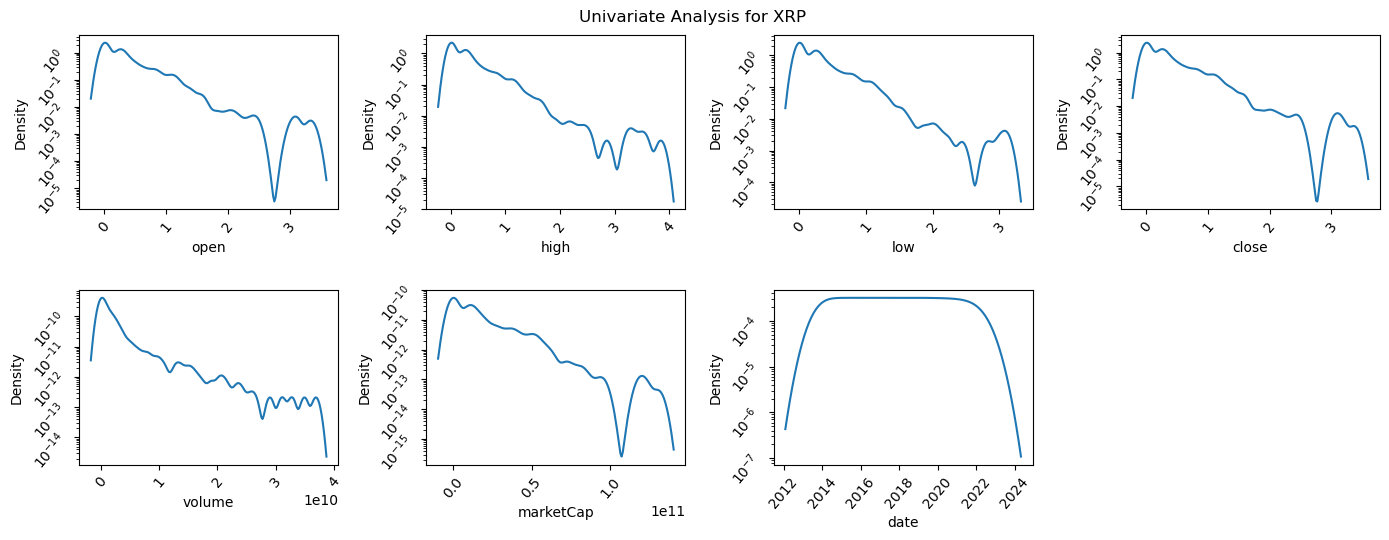

In [343]:
xrp_df = df[df['crypto_name'] == 'XRP']

plt.figure(figsize=[14, 10])
plt.suptitle('Univariate Analysis for XRP ')

for i, feature in enumerate(numeric_features):
    plt.subplot(4, 4, i + 1)
    sns.kdeplot(data=xrp_df, x=feature)
    plt.xticks(rotation=50, fontsize=10, color='black')
    plt.yticks(rotation=50, fontsize=10, color='black')
    plt.yscale('log')
    plt.xlabel(feature)

plt.tight_layout()
plt.show()

**XRP**
- **open, high, low, close**: These are also very similar to each other. The distributions are strongly right-skewed: most observations are at relatively low prices, while a smaller number occur at much higher prices.
- **volume**: Strong right skew with many fluctuations. XRP has substantial variation in trading volume across the period.
- **marketCap**: Strongly right-skewed and has noticeable irregularities/dips, indicating different market-cap regimes over time.
- **date**: The observations cover approximately 2012–2024, with the density relatively broad through much of that period.

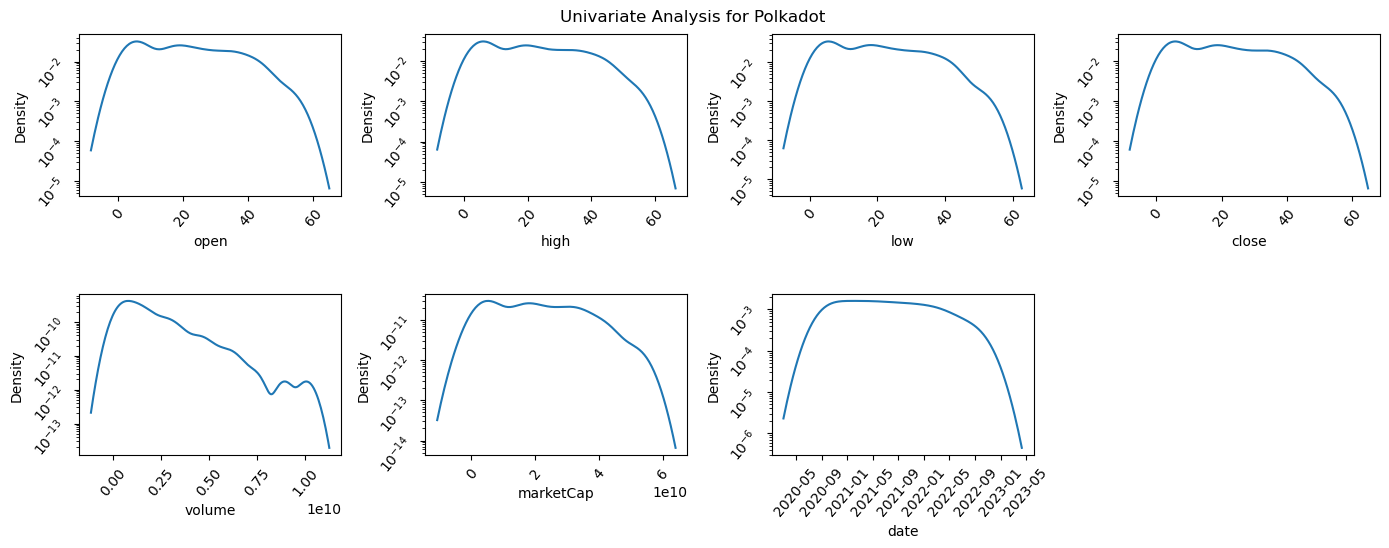

In [344]:
Pol_df = df[df['crypto_name'] == 'Polkadot']

plt.figure(figsize=[14, 10])
plt.suptitle('Univariate Analysis for Polkadot ')

for i, feature in enumerate(numeric_features):
    plt.subplot(4, 4, i + 1)
    sns.kdeplot(data=Pol_df, x=feature)
    plt.xticks(rotation=50, fontsize=10, color='black')
    plt.yticks(rotation=50, fontsize=10, color='black')
    plt.yscale('log')
    plt.xlabel(feature)

plt.tight_layout()
plt.show()

**Polkadot**
- **open, high, low, close**: Very similar distributions, which is expected because these four prices are closely related. Most observations are concentrated roughly in the lower-to-middle price range, with a long right tail toward higher prices.
- **volume**: Highly irregular and strongly skewed. There are several local peaks, suggesting periods with very different trading-volume regimes.
- **marketCap**: Also right-skewed, with most observations at lower values and a long tail toward larger market caps.
- **date**: The distribution is relatively broad over the dataset's time period, rather than being concentrated at one point.

## Bivariate Analysis

(4, 2)


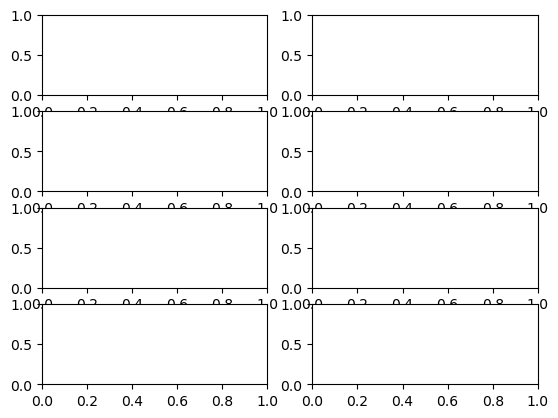

In [345]:
fig, ax = plt.subplots(nrows= 4,ncols=2)
print(ax.shape)

### Opening Price analysis of top crypto 

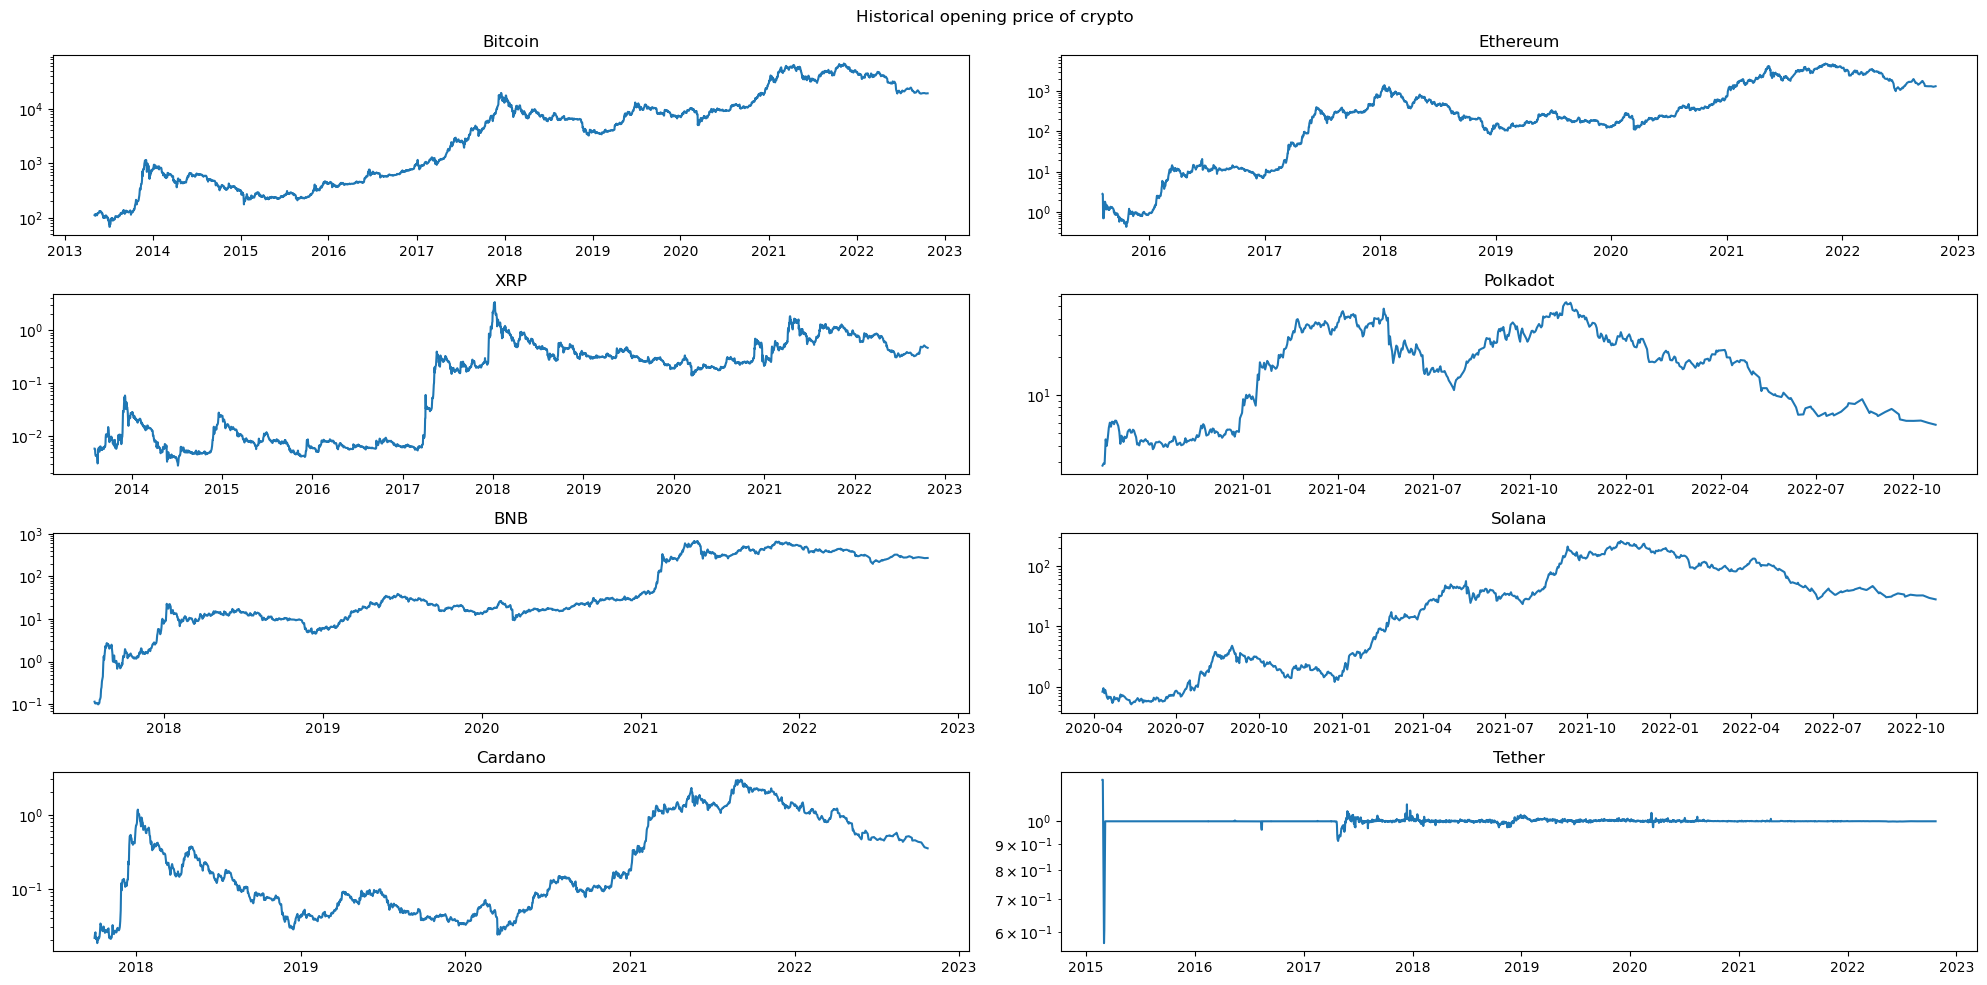

In [346]:
fig, axes = plt.subplots(nrows= 4,ncols= 2,figsize=(20, 10))
fig.suptitle("Historical opening price of crypto")
axes = axes.flatten() # Because subplots return list of lists flatten used to optain simple list of axes
for ax,crypto_df, name in zip(axes,top_crypto,names):
        ax.plot(crypto_df['date'],crypto_df['open'])
        ax.set_yscale('log')
        ax.set_title(name)
plt.tight_layout()
plt.show()
        

- **Bitcoin**: 2018 peak ~$20K, 2021 peak ~$65K. Currently (end of series, ~late 2022) trading around $20K, i.e. back near the 2018 high.
- **Ethereum**: 2018 peak ~$1,400, 2021 peak ~$4,800. Similar retracement pattern.
- **XRP**: Sharp, narrow 2018 spike (~$3.3) that dwarfs its 2021 peak (~$1.8) — unusual vs. the others, suggesting 2018 was its true speculative top.
- **BNB, Solana, Polkadot, Cardano**: All show negligible price action before 2020–21, then a steep single 2021 blow-off top, since these tokens either launched later or were dormant earlier.
- **Tether**: Flat at ~$1.00 throughout (as expected for a stablecoin), with a couple of visible depeg wobbles (notably around 2017–2018 and minor noise elsewhere).

### market Cap Analysis of top crypto by time

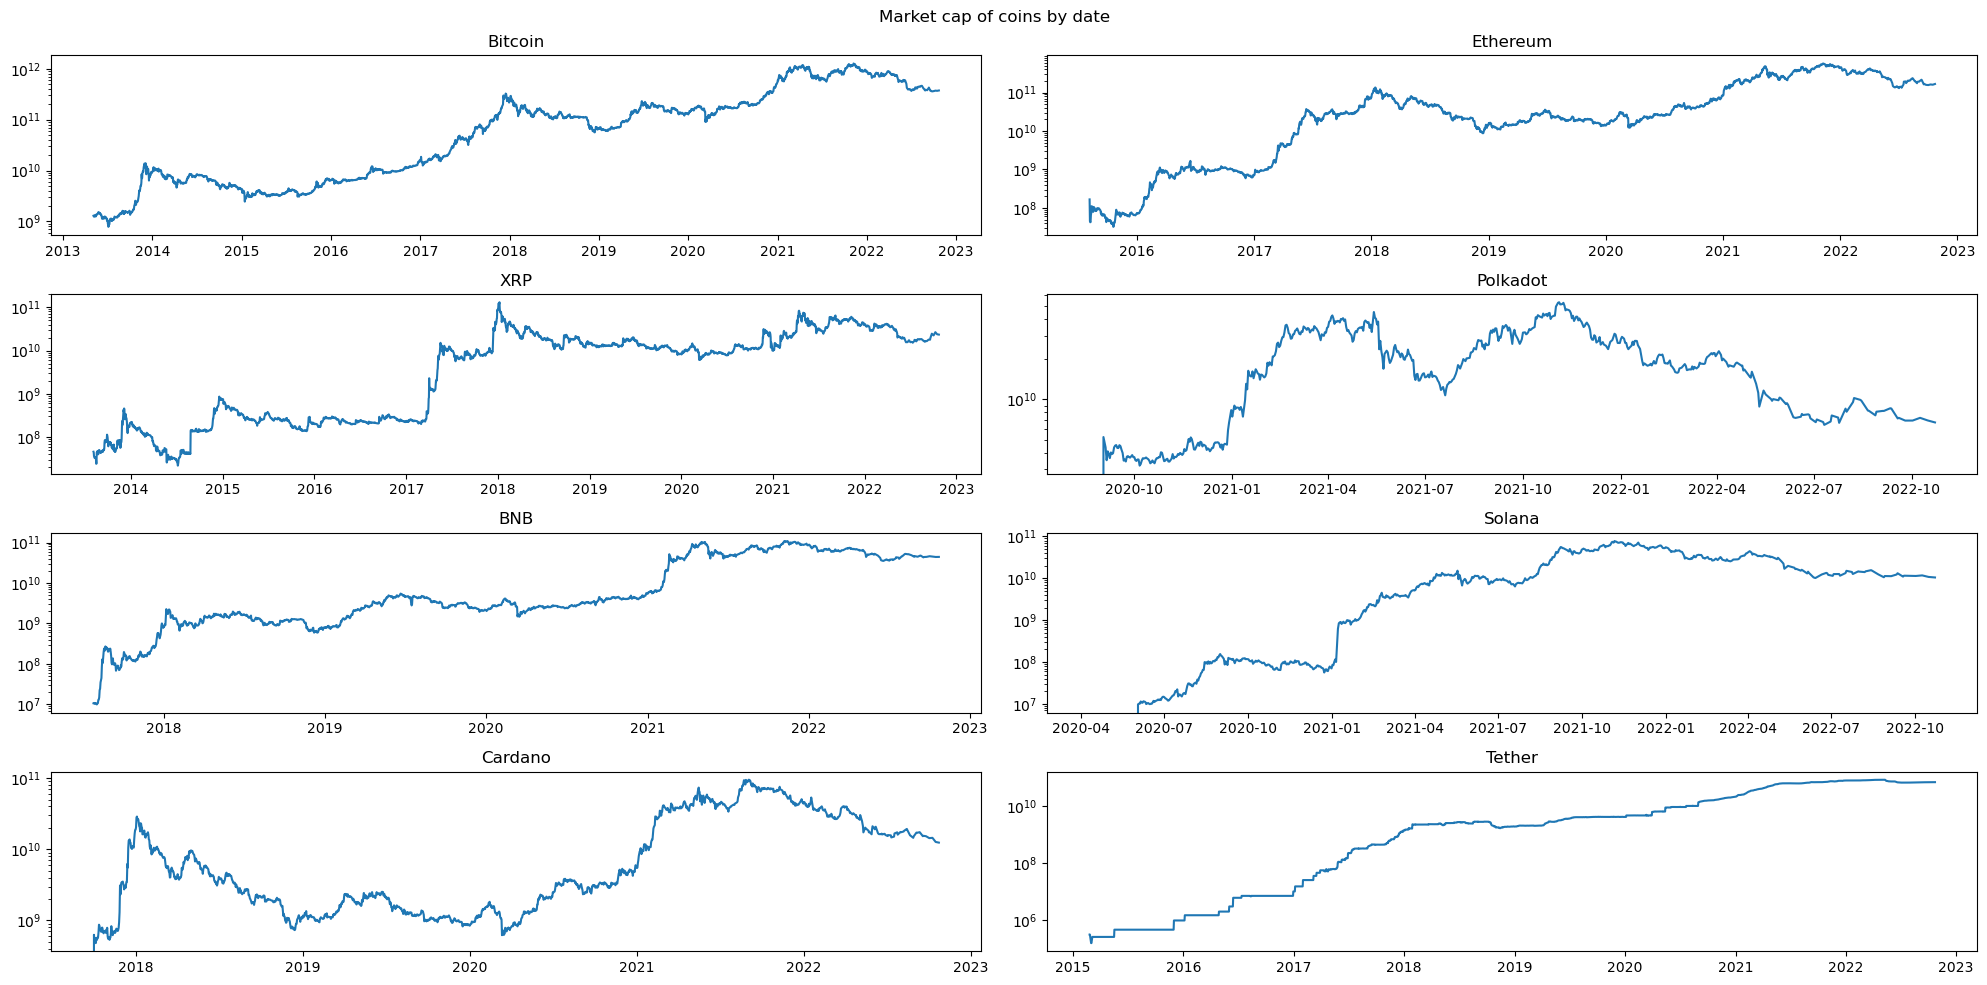

In [347]:
fig, axes = plt.subplots(nrows= 4,ncols= 2,figsize=(20, 10))
fig.suptitle("Market cap of coins by date")
axes = axes.flatten() # Because subplots return list of lists flatten used to optain simple list of axes
for ax,crypto_df, name in zip(axes,top_crypto,names):
        ax.plot(crypto_df['date'],crypto_df['marketCap'])
        ax.set_yscale('log')
        ax.set_title(name)
plt.tight_layout()
plt.show()

#### Market Capitalization:
    *Market Capitalization = Price *  Supply

**Bitcoin**: Market cap peaked just above $1.1–1.2 trillion in late 2021, versus ~$0.25T at the 2018 peak — roughly a 4–5x jump in total valuation between cycles.
**Ethereum**: Peaked around $0.5 trillion (5e11) in 2021 vs. a much smaller 2018 bump — a proportionally larger cycle-over-cycle gain than Bitcoin.
**XRP**: Market cap peak (~1e11) in 2018 actually exceeds its 2021 peak — consistent with the price chart's finding that XRP's 2018 spike was its true top, even accounting for supply growth.
**BNB, Solana, Polkadot, Cardano**: All essentially flat/negligible market cap until 2020–21, then a fast run-up to peaks in the 5e10–1e11 range, then decay — these are supply-and-price-driven together since token issuance was still ramping through this period.
**Tether**: This is the most different from the price chart — instead of a flat line, market cap shows steady, almost monotonic growth from ~0 to ~7.5e10 (from 2015 to 2022), with a steep ramp starting ~2020. This reflects stablecoin issuance/minting growing with demand, since price stays pegged at $1 but supply keeps expanding — Tether's market cap is really a proxy for how much USDT has been minted over time.

### Trading volume Analysis

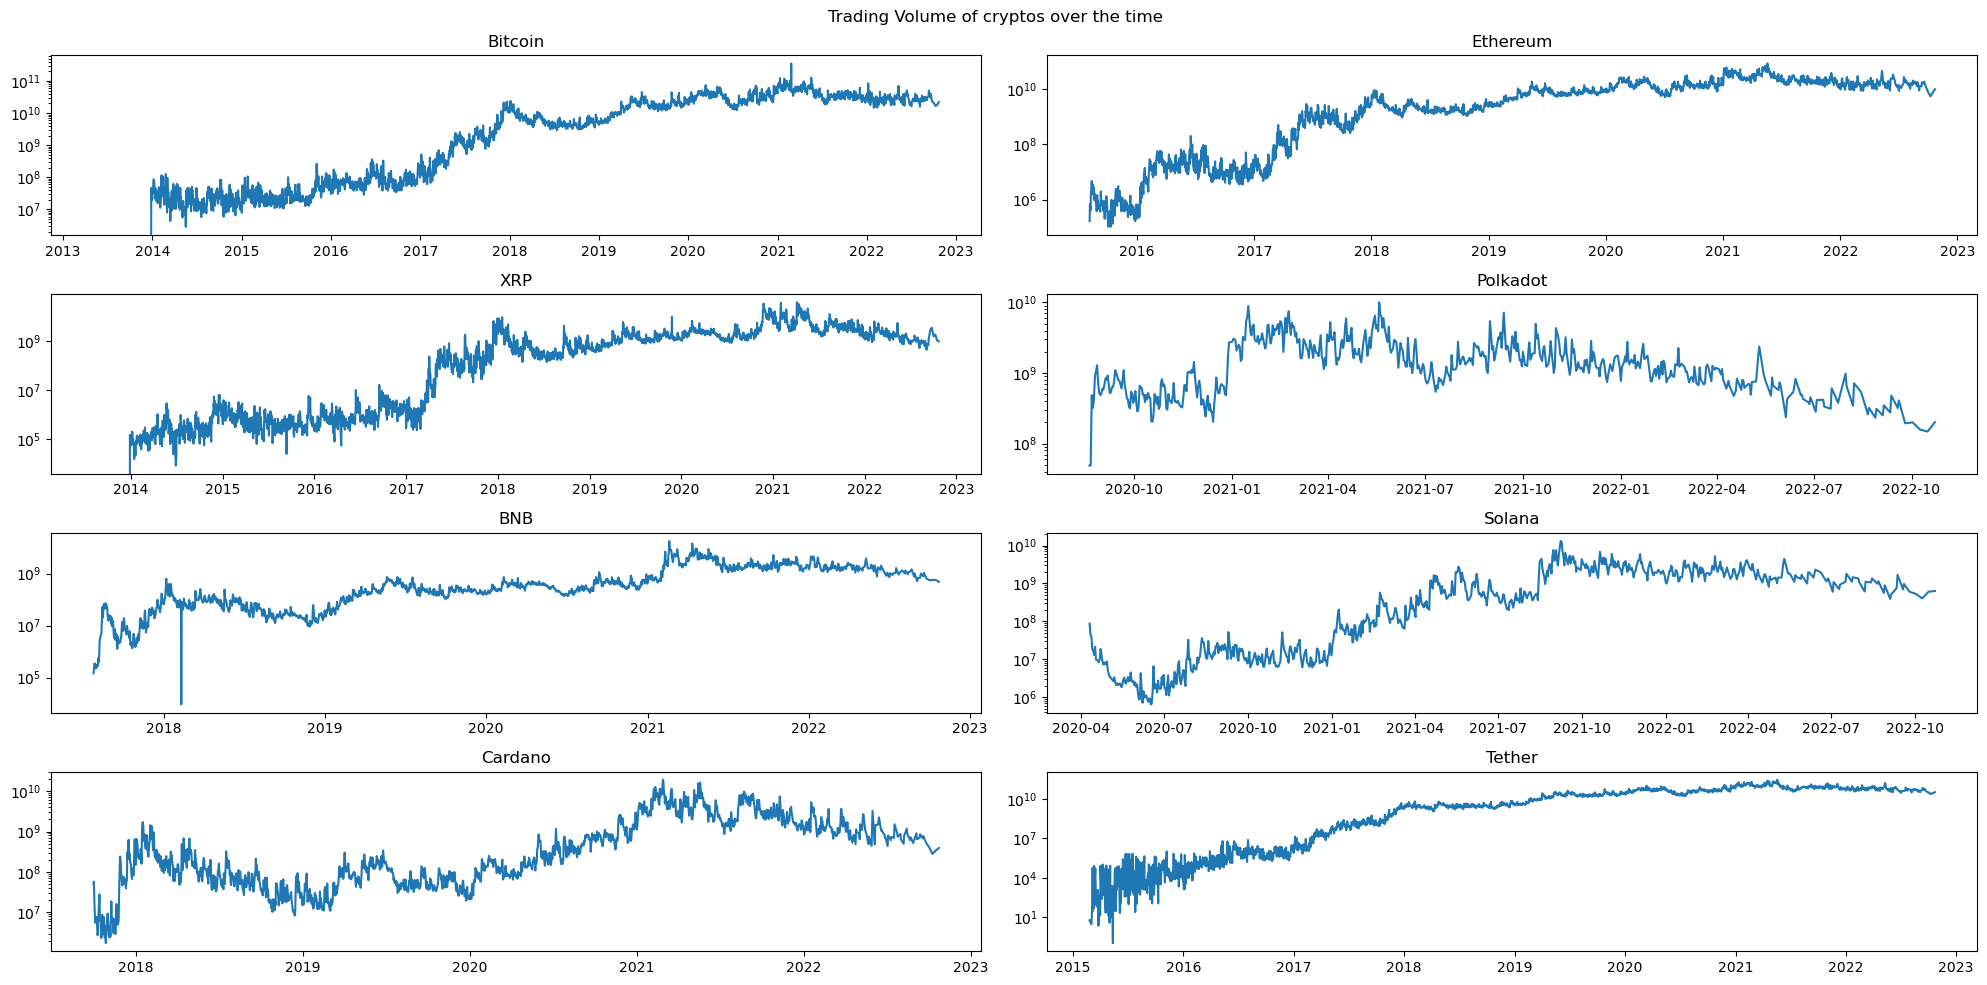

In [348]:
fig, axes = plt.subplots(nrows= 4,ncols= 2,figsize=(20, 10))
fig.suptitle("Trading Volume of cryptos over the time")
axes = axes.flatten() # Because subplots return list of lists flatten used to optain simple list of axes
for ax,crypto_df, name in zip(axes,top_crypto,names):
        ax.plot(crypto_df['date'],crypto_df['volume'])
        ax.set_yscale('log')
        ax.set_title(name)
plt.tight_layout()
plt.show()

- **Bitcoin**: Volume grew fairly smoothly from 2014 to a stable plateau from 2018 onward, with 2021 pushing modestly above that plateau — Gradual and Structural Increase.
- **Ethereum, XRP, Cardano, BNB, Solana, Polkadot**: All show the same pattern — noisy but clear upward trend from listing, reaching a fairly stable high-volume "regime" by 2020–21, then roughly flat (with noise) through 2022.
- **Tether**: exponential growth from 2015 to 2019 — four orders of magnitude — before plateauing. This is a genuinely different insight: Tether's volume didn't start high, it became the dominant trading pair over ~4 years.

### Analysing high and low  of  coins over time

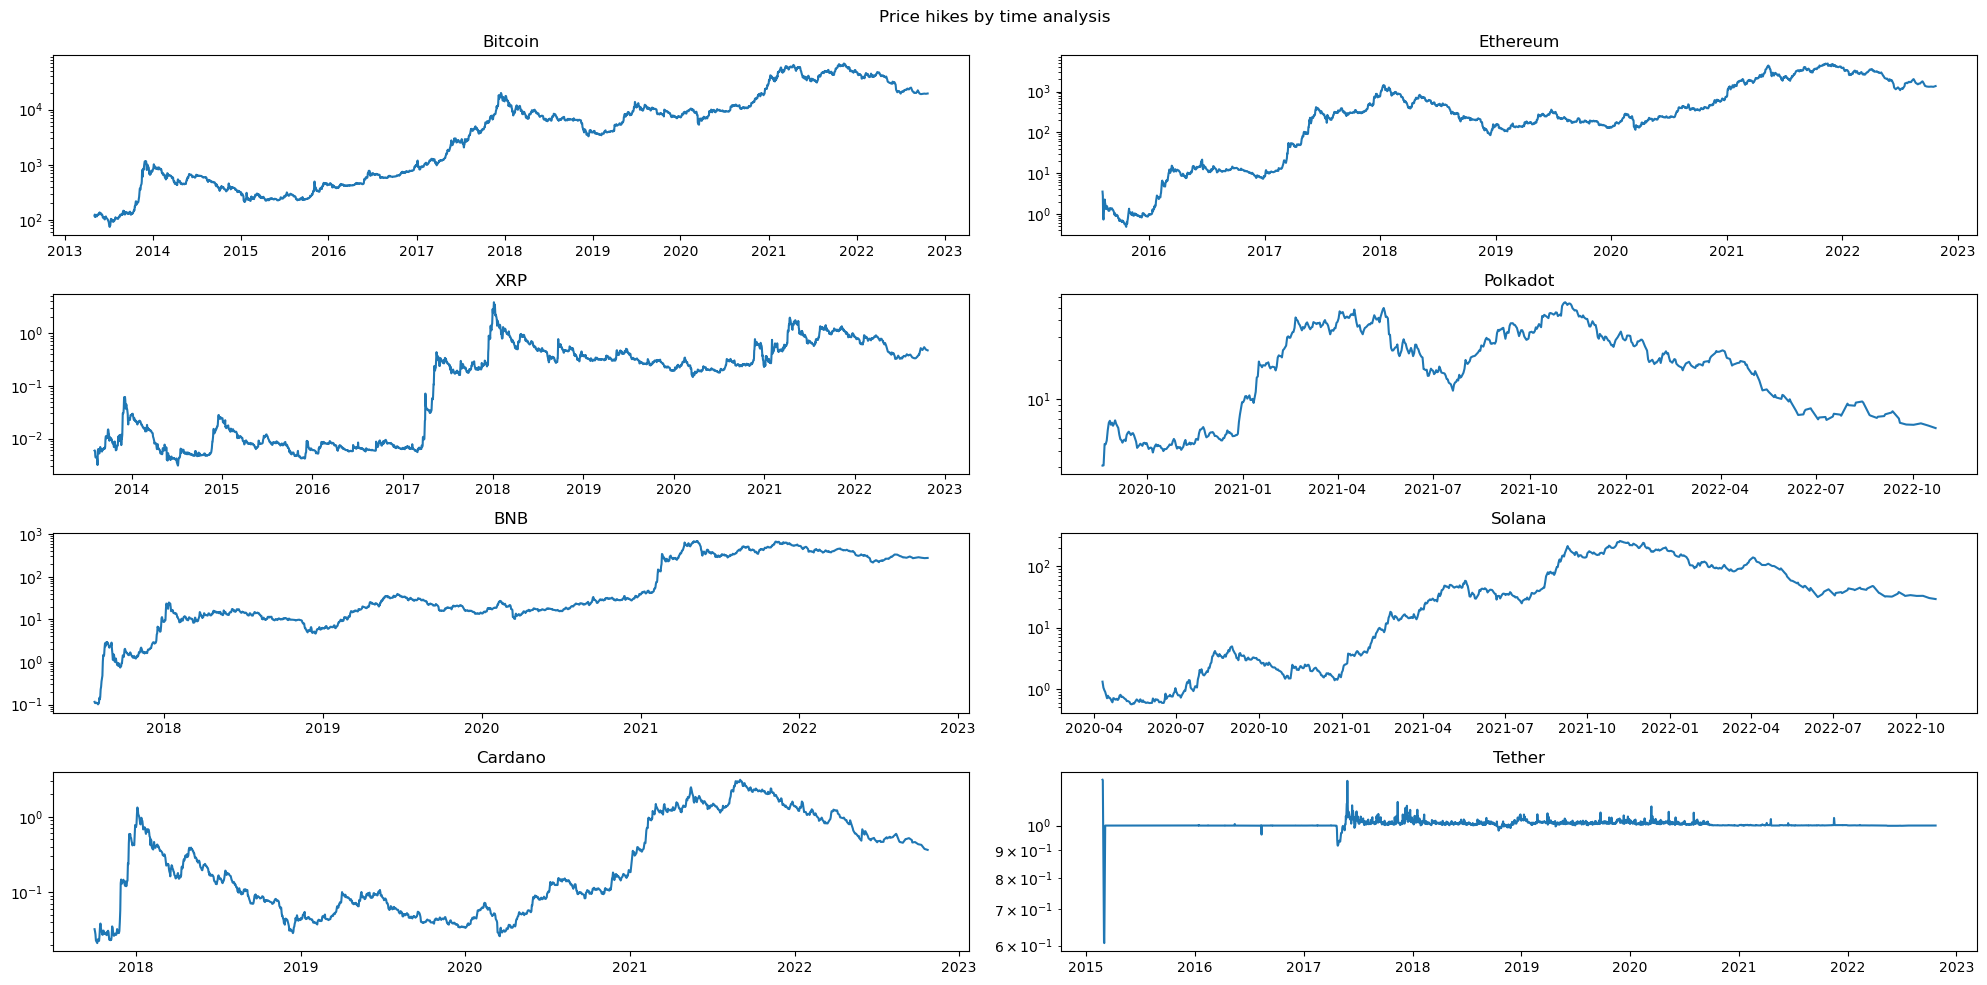

In [349]:
fig, axes = plt.subplots(nrows= 4,ncols= 2,figsize=(20, 10))
fig.suptitle("Price hikes by time analysis")
axes = axes.flatten() # Because subplots return list of lists flatten used to optain simple list of axes
for ax,crypto_df, name in zip(axes,top_crypto,names):
        ax.plot(crypto_df['date'],crypto_df['high'])
        ax.set_yscale('log')
        ax.set_title(name)
plt.tight_layout()
plt.show()

- **Bitcoin**: Two clearly comparable exponential run-ups — ~$100→$20K (2013–17, ~200x) and ~$3K→$65K (2019–21, ~20x). The first cycle was actually the larger percentage move.
- **Ethereum**: Similar pattern — steady exponential climb from <$1 (2015) to ~$1,400 (2018), then another leg to ~$4,800 (2021). Both legs look like comparable-magnitude moves here.
- **XRP**: Now the 2018 spike looks less like a singular anomaly and more like the top of a longer climb from ~$0.01 (2014) — though it's still the sharpest, most vertical spike of any coin here, even on log scale.
- **BNB, Solana, Polkadot, Cardano**: solana went from <1$ to ~200+$ pick in 2021 shows genuine exceptional growth in altcoins, smooth multi curve clib in price.
- **Tether**: The depeg spikes (2015, and especially a sharp one around 2017) are now much more visually prominent since log scale amplifies small deviations from $1 — worth flagging that ~2017 spike specifically as a data point to check (possible data error vs. real depeg event).

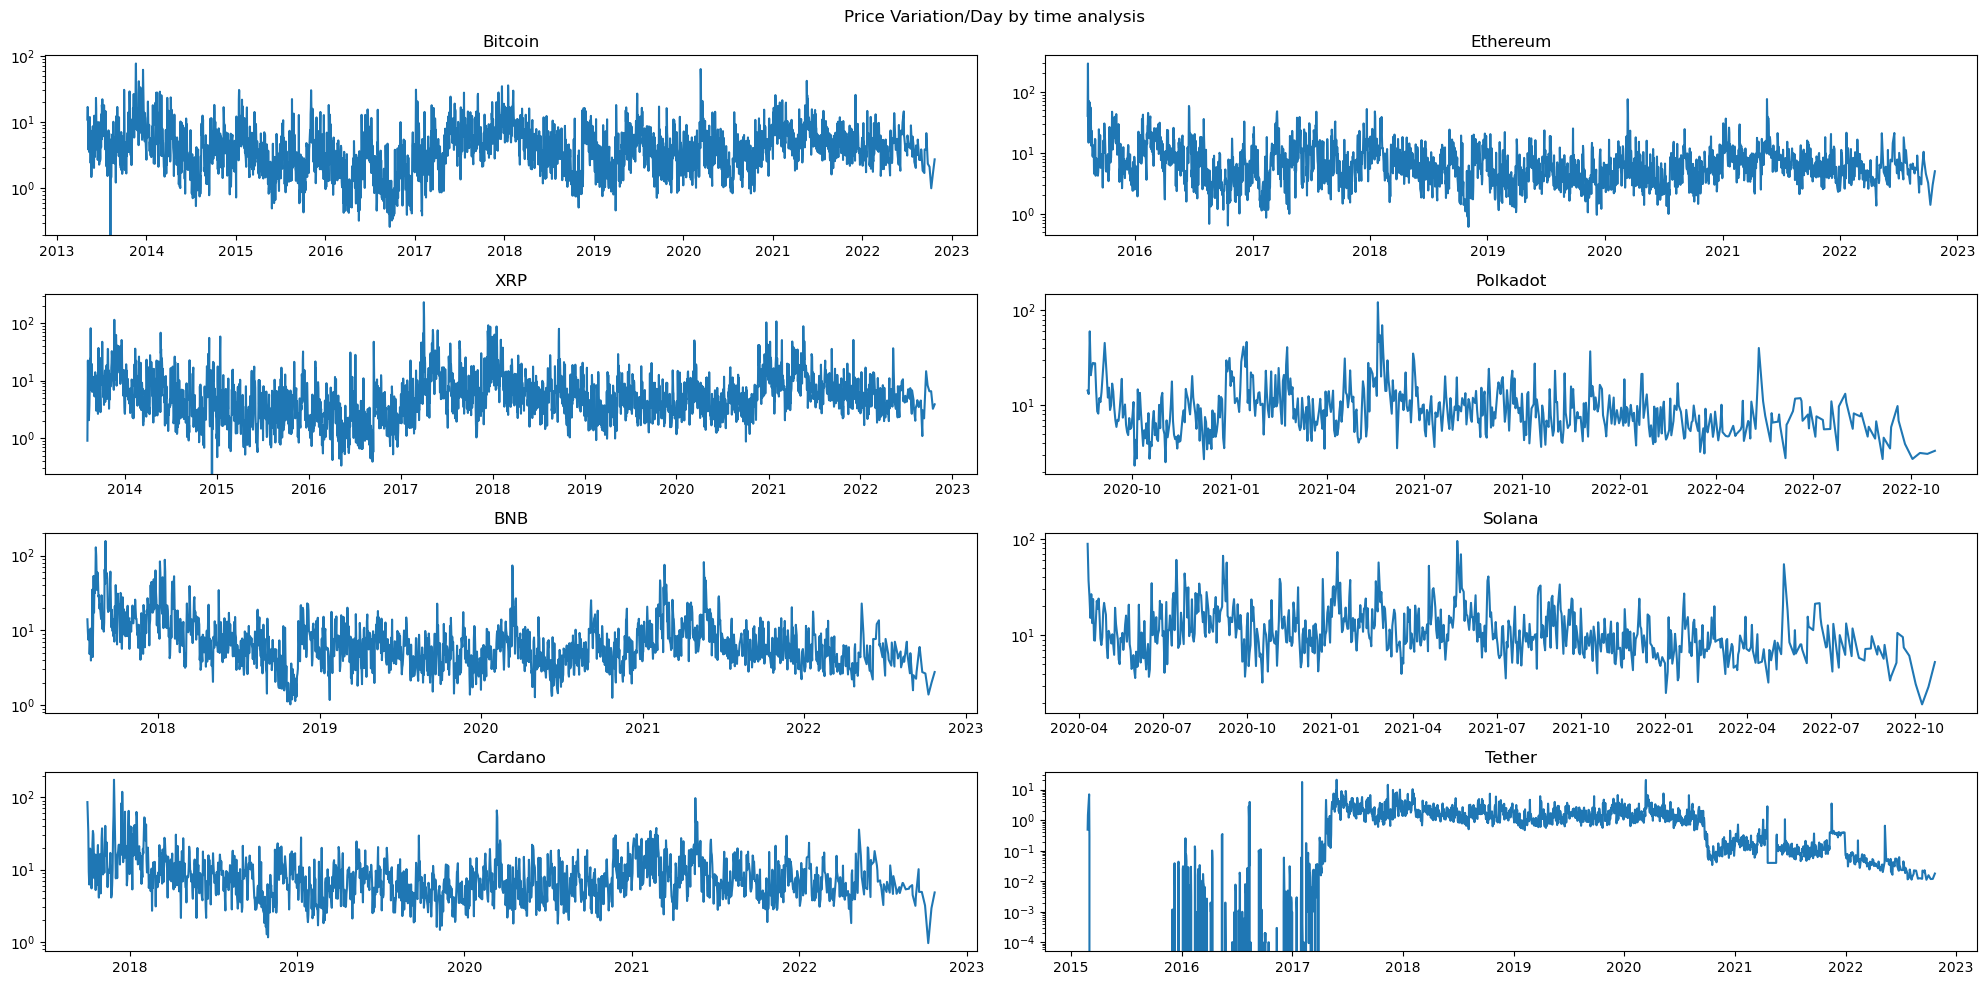

In [350]:
fig, axes = plt.subplots(nrows= 4,ncols= 2,figsize=(20, 10))
fig.suptitle("Price Variation/Day by time analysis")
axes = axes.flatten() # Because subplots return list of lists flatten used to optain simple list of axes
for ax,crypto_df, name in zip(axes,top_crypto,names):
        ax.plot(crypto_df['date'],crypto_df['variation'])
        ax.set_yscale('log')
        ax.set_title(name)
plt.tight_layout()
plt.show()

- **Bitcoin, Ethereum**: Both hover mostly in the ~1–10% daily range band, with occasional spikes to 20–50%+ — notably a sharp early outlier for Bitcoin around 2013–14 (looks like a single extreme day, possibly low-liquidity data or an error, worth checking).
- **XRP**: Consistently noisier than BTC/ETH — its "typical" band sits a bit higher (~2–20%) and spikes more frequently into the 50%+ region, consistent with it being a smaller-cap, more speculative asset throughout its history.
- **Polkadot, BNB, Solana, C"ardano**: Similar noisy band in the 1–20% range with frequent spikes to 50–100%, and — notably — Solana and Polkadot both show a sharp volatility spike right at the end of the series (late 2022), which lines up with real events (FTX collapse in Nov 2022) — worth flagging if  dataset extends that far, since it's a genuine risk-event signature, not noise.
- **Tether**: The most informative panel by far. Structurally different from every other coin — near-zero variation (10⁻⁴ to 10⁻² most of the time) once it stabilizes post-2017, but with a messy, highly volatile pre-2017 period full of extreme swings down to 10⁻⁴. That early noise is very likely a data quality issue (thin trading, bad ticks, or exchange listing artifacts) rather than genuine stablecoin instability — I'd treat pre-2017 Tether data with real skepticism before using it in any downstream analysis.+

### Multicolinearity check

In [355]:
numeric_df

,open,high,low,close,volume,marketCap
0,112.90,118.80,107.14,115.91,0.00,1288693175.50
1,3.49,3.69,3.35,3.59,0.00,62298185.43
2,115.98,124.66,106.64,112.30,0.00,1249023060.00
3,3.59,3.78,3.12,3.37,0.00,58594361.23
4,112.25,113.44,97.70,111.50,0.00,1240593600.00
...,...,...,...,...,...,...
72941,0.02,0.02,0.02,0.02,40401338.08,1652957186.63
72942,1.47,1.53,1.44,1.52,28443510.43,1572824923.08
72943,4.95,5.15,4.95,5.12,106949683.62,1559551358.49
72944,0.00,0.00,0.00,0.00,214326817.63,1576291167.45


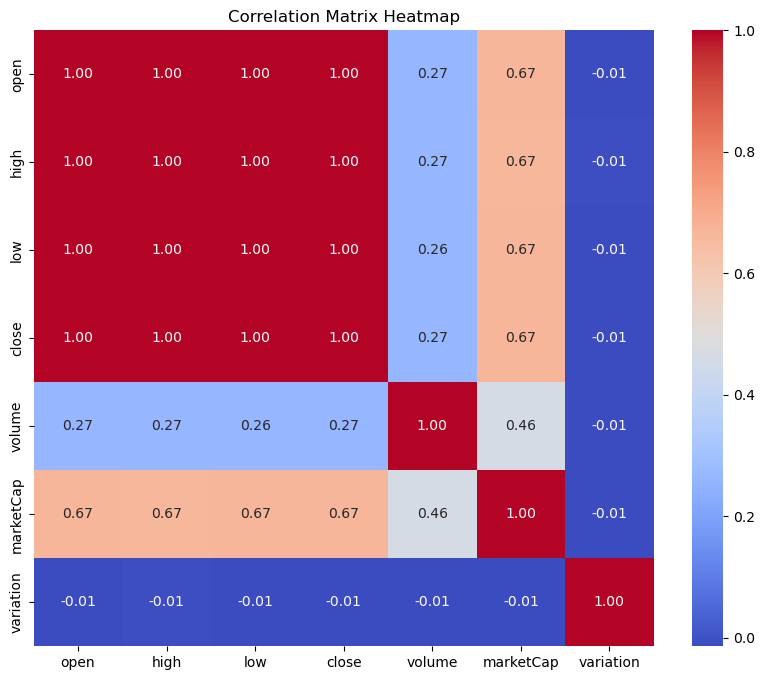

In [364]:
df1 = df.select_dtypes(include = 'number')
corr_matrix = df1.corr(method='pearson')
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

**Coliniarity Check**

- **Open, High, Low and Close** Columns arre perfectly Corelated to each other
- **Volume** Price Columns and volume columns are not much co- related
- **marketCap** and volume column are in descent co relation